# DBSCAN demo

Example script to test the DBSCAN clustering methods. DBSCAN demo from https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py
Great video explaining DBSCAN: https://www.youtube.com/watch?v=RDZUdRSDOok

In [1]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

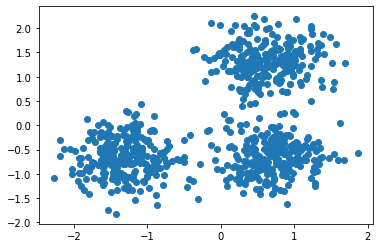

In [3]:
plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [4]:
db = DBSCAN(eps=0.5, min_samples=50).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 3


In [5]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.954
Completeness: 0.936
V-measure: 0.945
Adjusted Rand Index: 0.970
Adjusted Mutual Information: 0.945
Silhouette Coefficient: 0.623


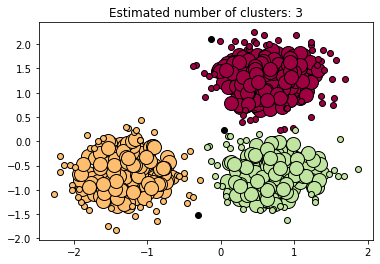

In [6]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

# HDBSCAN Demo
Now demo hdbscan: https://hdbscan.readthedocs.io/en/latest/basic_hdbscan.html
Great video explaining this concept: https://www.youtube.com/watch?v=dGsxd67IFiU

In [7]:
from sklearn.datasets import make_blobs
import pandas as pd
import hdbscan

In [8]:
blobs, labels = make_blobs(n_samples=2000, n_features=2, centers=6)
pd.DataFrame(blobs).head()

,0,1
0,8.502475,-7.506227
1,-1.778516,-4.092101
2,-1.989854,0.775204
3,4.755678,3.834500
4,-4.300168,-8.804036


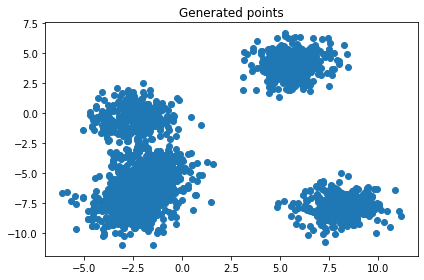

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(blobs[:, 0], blobs[:, 1])
ax.set_title('Generated points')
plt.tight_layout()
plt.show()

In [10]:
clusterer = hdbscan.HDBSCAN(algorithm='best', alpha=1.0, approx_min_span_tree=True,
    gen_min_span_tree=False, leaf_size=40,
    metric='euclidean', min_cluster_size=25, min_samples=None, p=None)
clusterer.fit(blobs)

C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,min_cluster_size,25
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,0
,metric,'euclidean'
,alpha,1.0
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)
,approx_min_span_tree,True


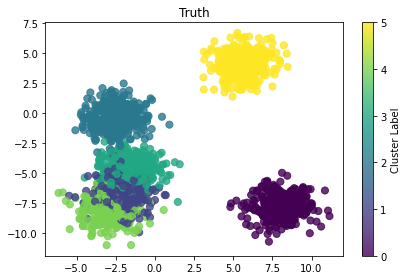

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(blobs[:, 0], blobs[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Cluster Label')
ax.set_title('Truth')

plt.tight_layout()
plt.show()

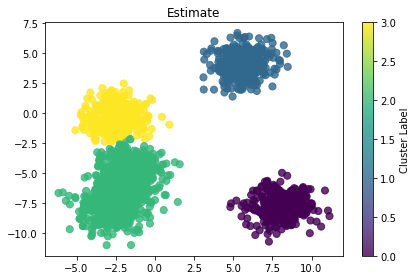

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

scatter = ax.scatter(blobs[:, 0], blobs[:, 1], c=clusterer.labels_, cmap='viridis', s=50, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Cluster Label')
ax.set_title('Estimate')

plt.tight_layout()
plt.show()

Now add noise.

In [13]:
# Number of noise points
n_noise = 1000

# Random 2D points within the blob range
x_min, x_max = blobs[:, 0].min(), blobs[:, 0].max()
y_min, y_max = blobs[:, 1].min(), blobs[:, 1].max()

noise_points = np.random.uniform(low=[x_min, y_min], high=[x_max, y_max], size=(n_noise, 2))
noise_labels = np.full(n_noise, -1)  # label -1 for noise

# Combine blobs and noise
all_points = np.vstack([blobs, noise_points])
all_labels = np.hstack([labels, noise_labels])

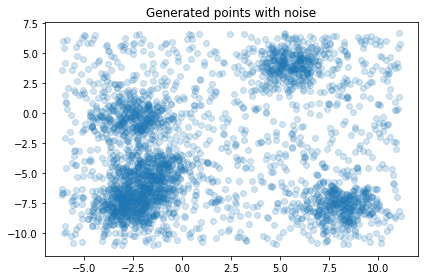

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(all_points[:, 0], all_points[:, 1], alpha=0.2)
ax.set_title('Generated points with noise')
plt.tight_layout()
plt.show()

In [15]:
clusterer = hdbscan.HDBSCAN(algorithm='best', alpha=1.0, approx_min_span_tree=True,
    gen_min_span_tree=False, leaf_size=40,
    metric='euclidean', min_cluster_size=25, min_samples=None, p=None)
clusterer.fit(all_points)

C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,min_cluster_size,25
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,0
,metric,'euclidean'
,alpha,1.0
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)
,approx_min_span_tree,True


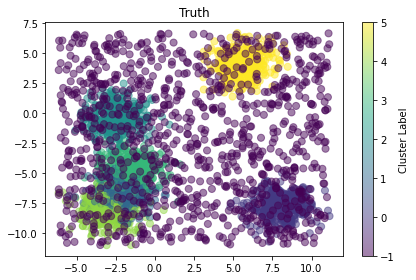

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

scatter = ax.scatter(all_points[:, 0], all_points[:, 1], c=all_labels, cmap='viridis', s=50, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='Cluster Label')
ax.set_title('Truth')

plt.tight_layout()
plt.show()

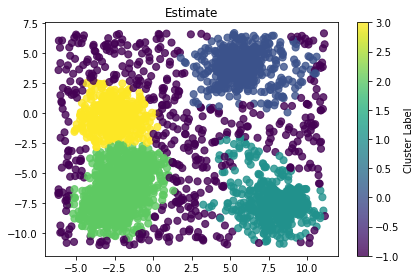

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

scatter = ax.scatter(all_points[:, 0], all_points[:, 1], c=clusterer.labels_, cmap='viridis', s=50, alpha=0.8)
plt.colorbar(scatter, ax=ax, label='Cluster Label')
ax.set_title('Estimate')

plt.tight_layout()
plt.show()

# Apply to CoBaLT data

Load in scatter plot.

In [523]:
# Imports and project root setup
import sys
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import time

# Determine project root: prefer __file__ when available (script), otherwise search upward for 'config/preprocessing.yaml'
def find_project_root(start_path: Path = Path.cwd()):
    p = start_path.resolve()
    for parent in [p] + list(p.parents):
        if (parent / 'config' / 'preprocessing.yaml').exists():
            return parent
    return start_path.resolve()

try:
    project_root = Path(__file__).resolve().parent.parent
except NameError:
    project_root = find_project_root()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# (Optional) configure matplotlib interactive backend, if you want interactive selectors in this notebook
# Uncomment one of the following depending on your environment:
# %matplotlib widget
# %matplotlib notebook
%matplotlib inline

# Import the DataPreprocessor class from the package
from processing.data_preprocessor_v2 import DataPreprocessor
from processing.processing_methods.data_loader import DataLoader
from processing.processing_methods.data_plotter import DataPlotter
from processing.processing_methods.data_processor import DataProcessor

# Load configuration and create the DataPreprocessor instance
config_path = project_root / 'config' / 'preprocessing_hdbscan.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)


In [524]:
dp = DataPreprocessor(config)
dp.loader = DataLoader(config)
dp.plotter = DataPlotter(config)
dp.processor = DataProcessor(config)

In [525]:
dp.loader.preprocess()

Detected Windows data directory: C:\Users\Grant\OneDrive - UCB-O365\ARSENL\Experiments\Cloud Measurements\First Light
Measurement time (behind 1 hour): 2025-12-02 20:22:04

Preprocessed data file(s) found. No need to create new one(s)...


Locating and loading relevant netcdf data chunks...

Including chunk #0: 0.00–7.01s overlaps 3.75–4.00s
File loaded.

✅ Full time range 3.75–4.00s covered by loaded chunks.
Loaded 1 files
Num points: 14361924

Starting to generate scatter plot...
Finished generating plot.
Time elapsed: 0.9 s
Starting to save image...
Finished saving plot.
Time elapsed: 1.8 s


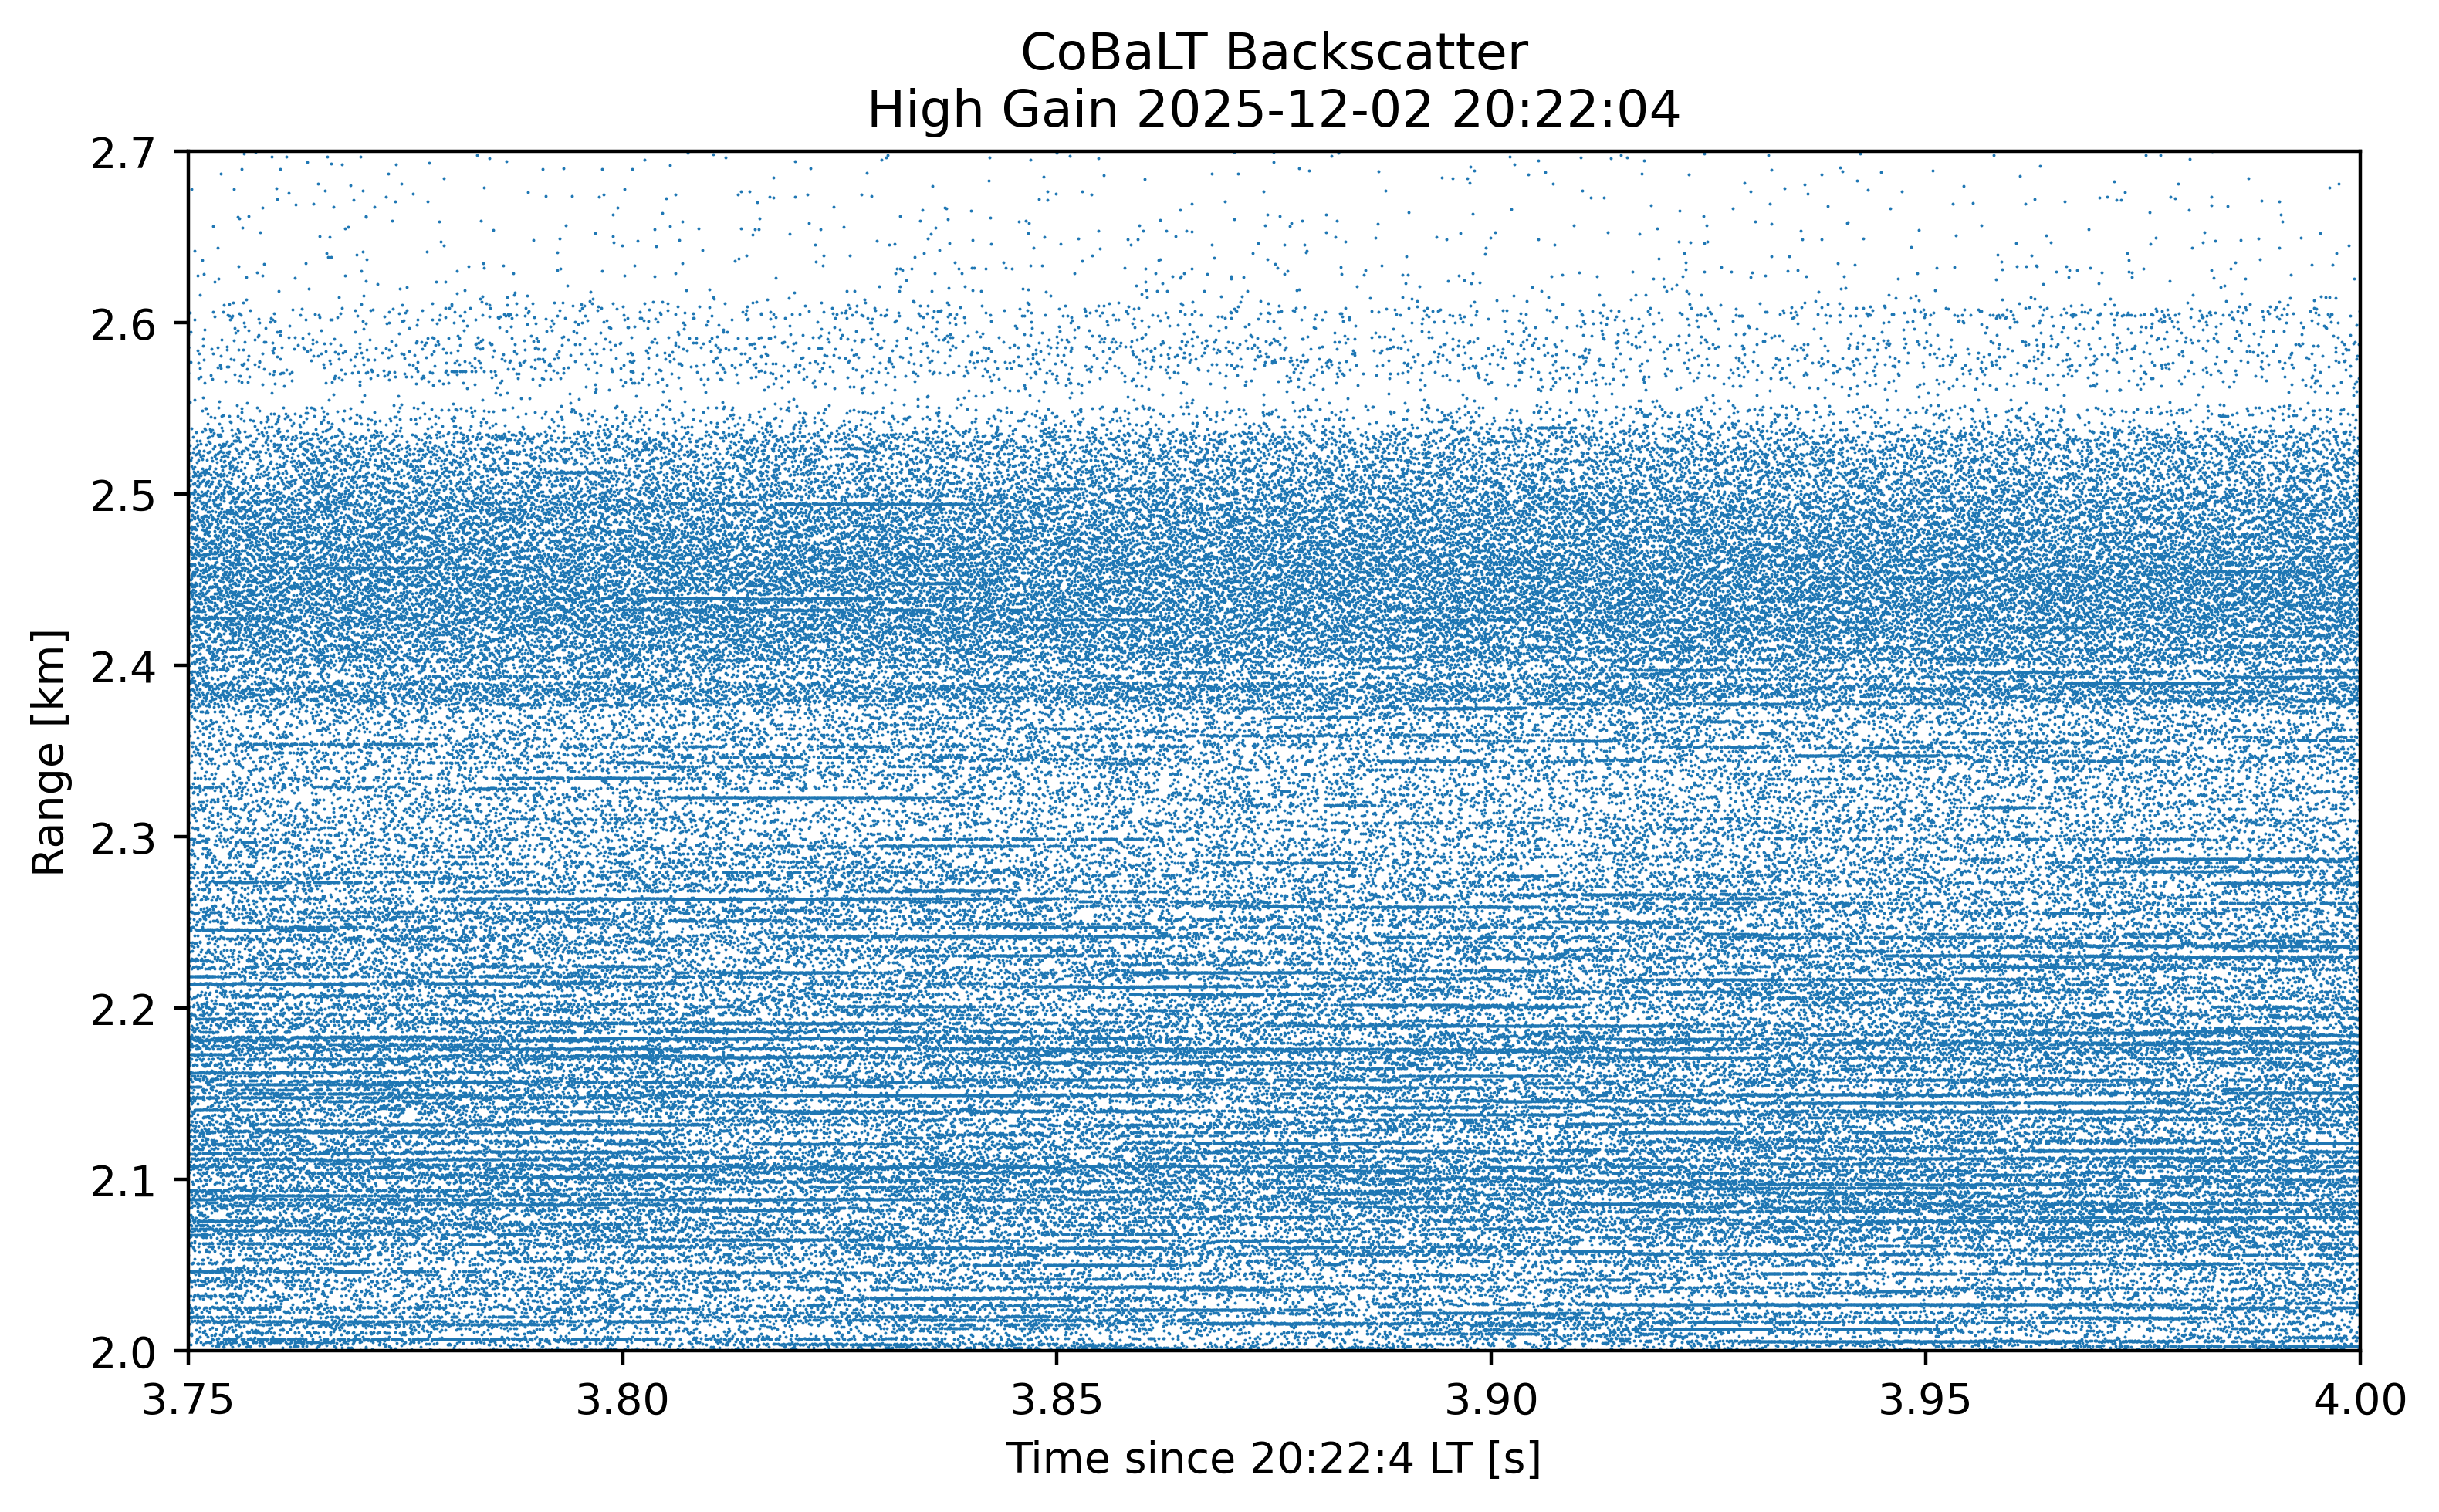

In [526]:
dp.plotter.plot_scatter(dp.loader)

In [527]:
dp.loader.load_chunk()

ranges = np.concatenate([da.values.ravel() for da in dp.loader.ranges_tot])
shots_time = np.concatenate([da.values.ravel() for da in dp.loader.shots_time_tot])

Locating and loading relevant netcdf data chunks...

Including chunk #0: 0.00–7.01s overlaps 3.75–4.00s
File loaded.

✅ Full time range 3.75–4.00s covered by loaded chunks.
Loaded 1 files


In [528]:
r0, r1 = dp.loader.ylim[0] * 1e3, dp.loader.ylim[1] * 1e3  # [km]
t0, t1 = dp.loader.xlim[0], dp.loader.xlim[1]  # [s]

mask = (
    (ranges >= r0) & (ranges <= r1) &
    (shots_time  >= t0) & (shots_time  <= t1)
)

filtered_ranges = ranges[mask]
filtered_times  = shots_time[mask]

print("Number of points: {}".format(filtered_ranges.size))

Number of points: 372342


In [529]:
CoBaLT_blobs = np.array([filtered_times, filtered_ranges]).T

# start = time.time()

# clusterer = hdbscan.HDBSCAN(algorithm='best', alpha=1.0, approx_min_span_tree=True,
#     gen_min_span_tree=False, leaf_size=40,
#     metric='euclidean', min_cluster_size=40, min_samples=250, p='euclidean')
# clusterer.fit(CoBaLT_blobs)

# print('Time elapsed: {:.2f} s'.format(time.time() - start))

In [538]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(CoBaLT_blobs)
X_reduced = PCA(n_components=2).fit_transform(X_scaled)

start = time.time()

clusterer = hdbscan.HDBSCAN(algorithm='best', alpha=1.0, approx_min_span_tree=True,
    gen_min_span_tree=False, leaf_size=40,
    metric='euclidean', min_cluster_size=5, min_samples=100, p='euclidean')
clusterer.fit(X_reduced)

print('Time elapsed: {:.2f} s'.format(time.time() - start))

X_original = scaler.inverse_transform(X_scaled)

C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Time elapsed: 46.72 s


Num clusters: 7


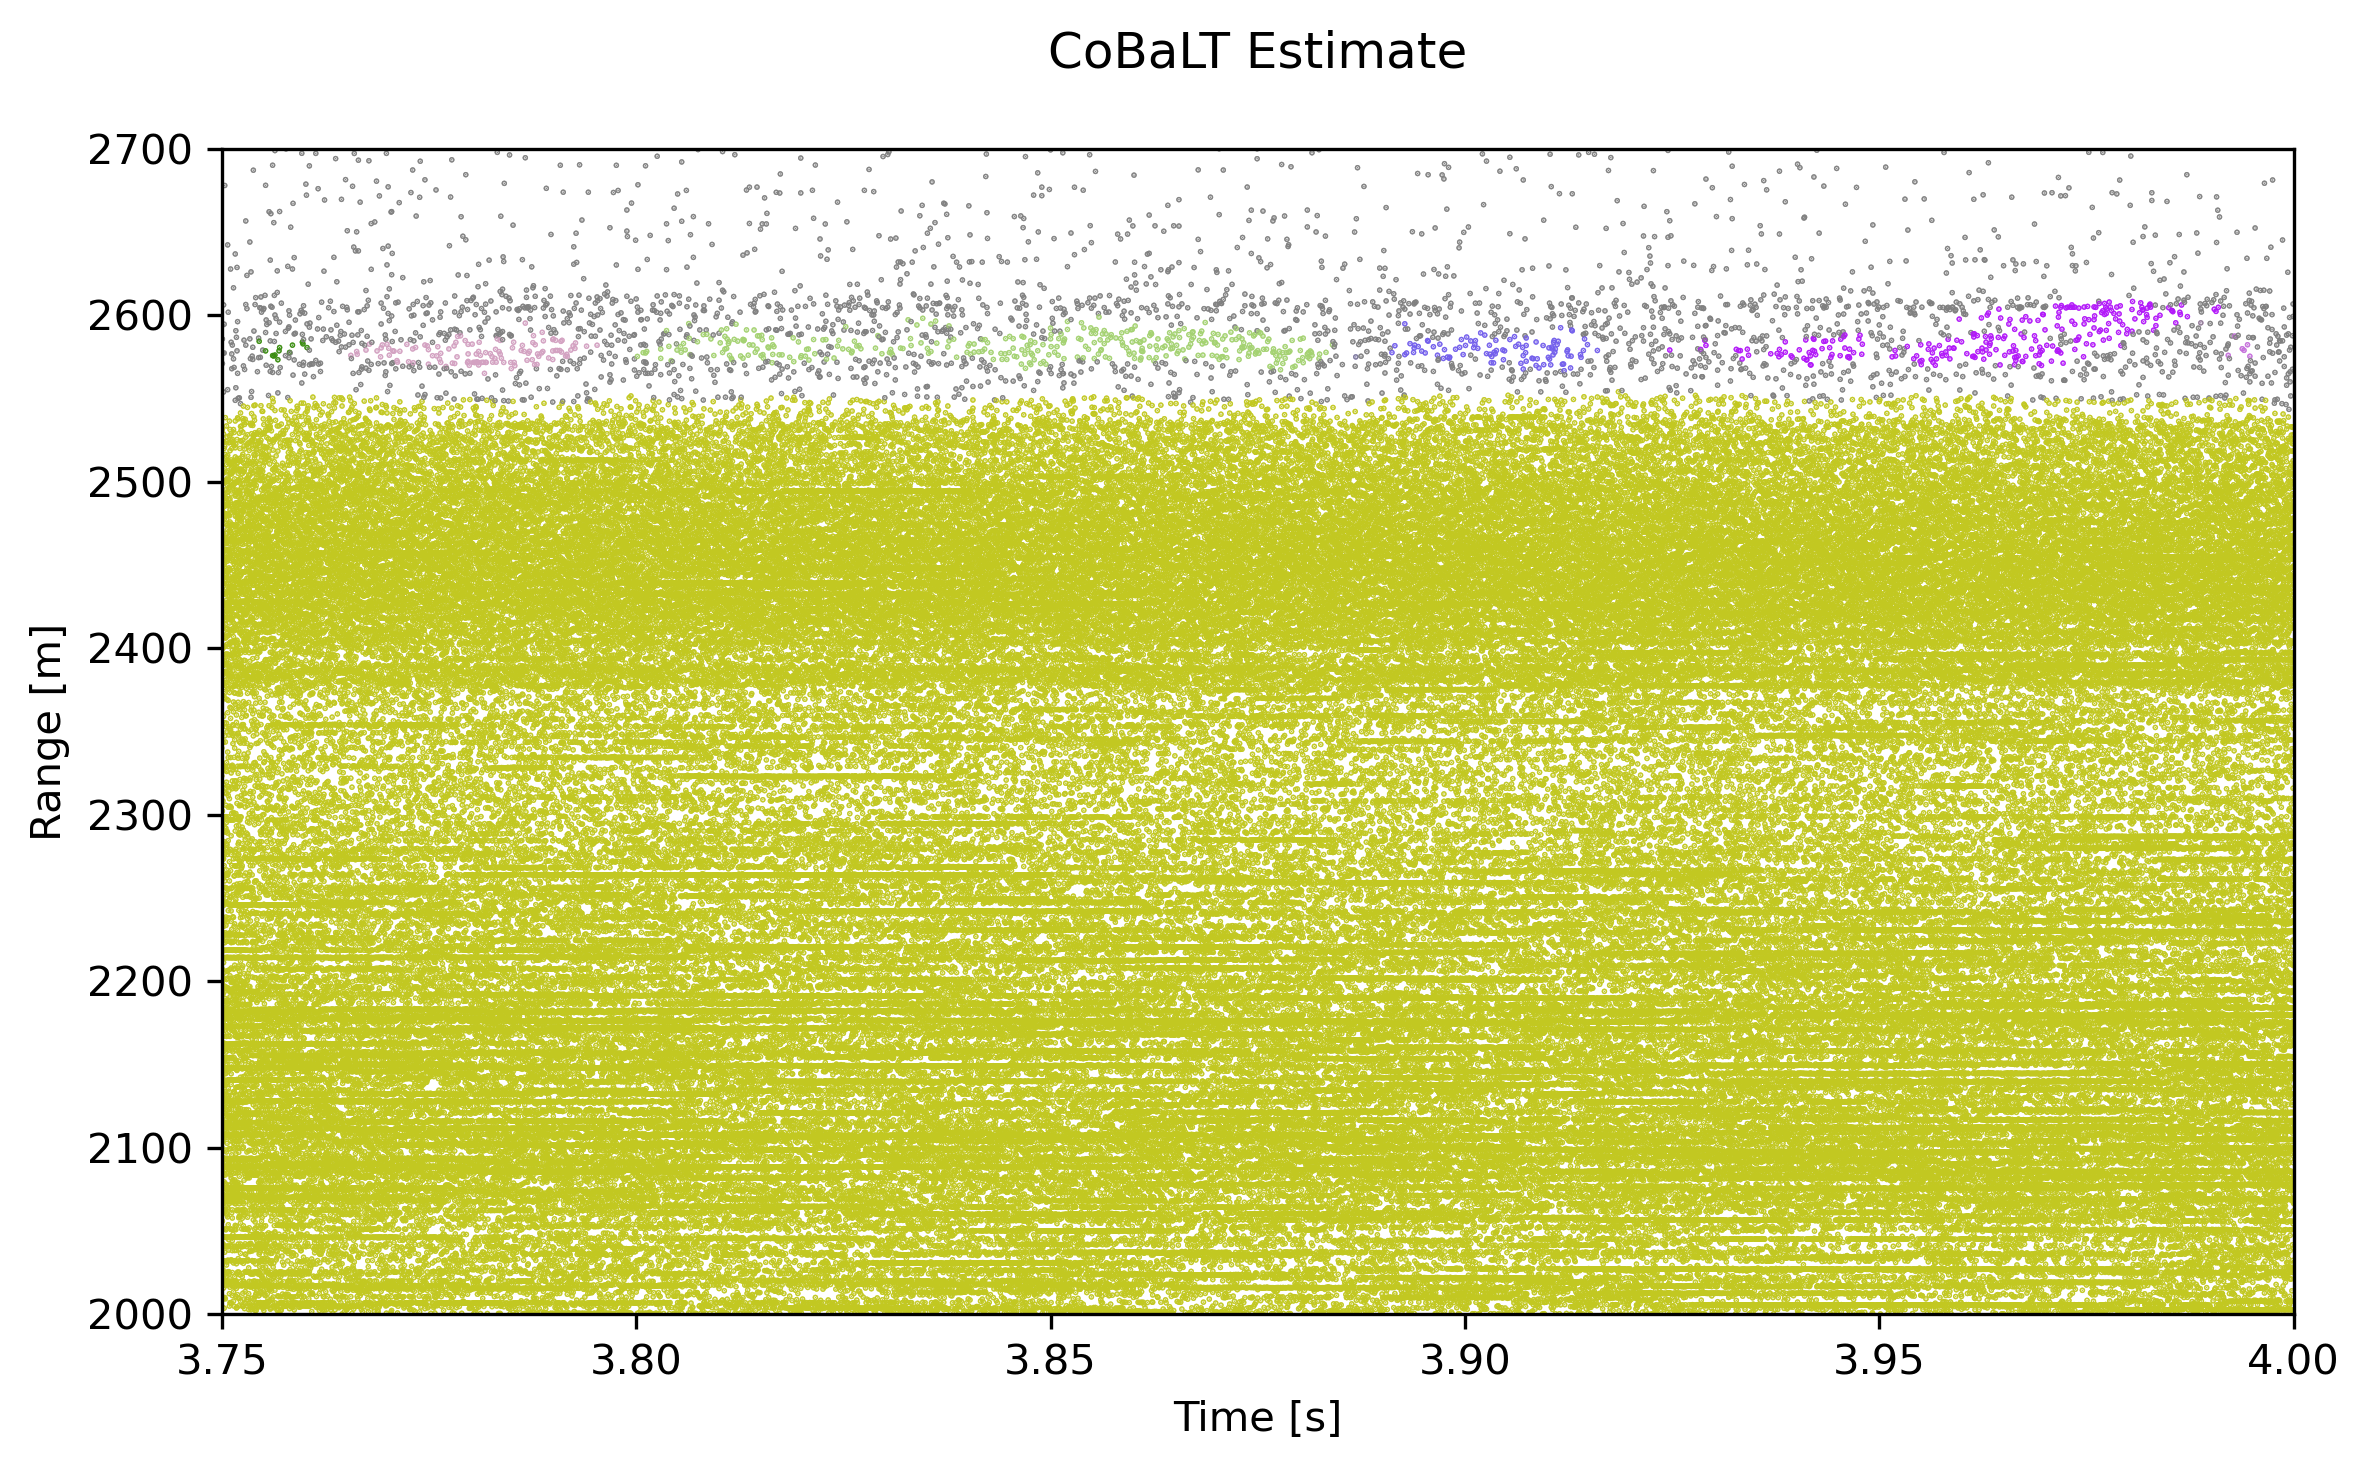

In [539]:
fig = plt.figure(figsize=(8, 5), dpi=300)
ax = fig.add_subplot(111)

labels = clusterer.labels_
unique_labels = np.unique(labels)

# Separate noise (-1) from real clusters
cluster_labels = unique_labels[unique_labels >= 0]
print('Num clusters: {}'.format(len(cluster_labels)))

# Generate random colors for real clusters
rng = np.random.default_rng(42)  # reproducible
colors = rng.random((len(cluster_labels), 3))

# Assign colors
label_to_color = {label: colors[i] for i, label in enumerate(cluster_labels)}

# Add a fixed color for noise
noise_color = np.array([0.5, 0.5, 0.5])  # gray
label_to_color[-1] = noise_color

# Build per-point color array
point_colors = np.array([label_to_color[label] for label in labels])

# scatter = ax.scatter(CoBaLT_blobs[:, 0], CoBaLT_blobs[:, 1], c=point_colors, cmap='viridis', s=5, alpha=0.8)
scatter = ax.scatter(X_original[:, 0], X_original[:, 1], c=point_colors, cmap='viridis', s=0.1, alpha=0.8)
# plt.colorbar(scatter, ax=ax, label='Cluster Label')
ax.set_title('CoBaLT Estimate\n')
ax.set_ylabel('Range [m]')
ax.set_xlabel('Time [s]')
ax.set_xlim([t0, t1])
ax.set_ylim([r0, r1])

plt.tight_layout()
plt.show()

# Gaussian Mixture Model Demo
Info on Gaussian mixture model from scikit-learn: https://scikit-learn.org/stable/modules/mixture.html#gmm

In [6]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold

colors = ["navy", "turquoise", "darkorange"]


def make_ellipses(gmm, ax):
    for n, color in enumerate(colors):
        if gmm.covariance_type == "full":
            covariances = gmm.covariances_[n][:2, :2]
        elif gmm.covariance_type == "tied":
            covariances = gmm.covariances_[:2, :2]
        elif gmm.covariance_type == "diag":
            covariances = np.diag(gmm.covariances_[n][:2])
        elif gmm.covariance_type == "spherical":
            covariances = np.eye(gmm.means_.shape[1]) * gmm.covariances_[n]
        v, w = np.linalg.eigh(covariances)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180 * angle / np.pi  # convert to degrees
        v = 2.0 * np.sqrt(2.0) * np.sqrt(v)
        ell = mpl.patches.Ellipse(
            gmm.means_[n, :2], v[0], v[1], angle=180 + angle, color=color
        )
        ell.set_clip_box(ax.bbox)
        ell.set_alpha(0.5)
        ax.add_artist(ell)
        ax.set_aspect("equal", "datalim")


In [7]:
iris = datasets.load_iris()

# Break up the dataset into non-overlapping training (75%) and testing
# (25%) sets.
skf = StratifiedKFold(n_splits=4)
# Only take the first fold.
train_index, test_index = next(iter(skf.split(iris.data, iris.target)))


X_train = iris.data[train_index]
y_train = iris.target[train_index]
X_test = iris.data[test_index]
y_test = iris.target[test_index]

n_classes = len(np.unique(y_train))

# Try GMMs using different types of covariances.
estimators = {
    cov_type: GaussianMixture(
        n_components=n_classes, covariance_type=cov_type, max_iter=20, random_state=0
    )
    for cov_type in ["spherical", "diag", "tied", "full"]
}

n_estimators = len(estimators)

C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmea

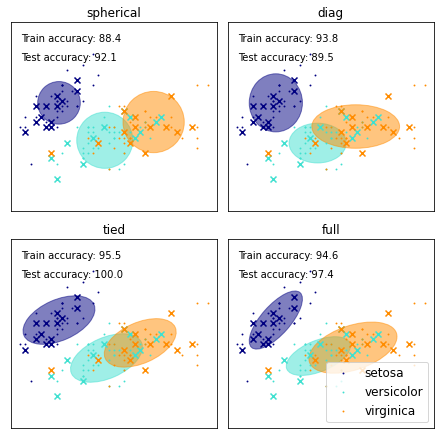

In [8]:
plt.figure(figsize=(3 * n_estimators // 2, 6))
plt.subplots_adjust(
    bottom=0.01, top=0.95, hspace=0.15, wspace=0.05, left=0.01, right=0.99
)
for index, (name, estimator) in enumerate(estimators.items()):
    # Since we have class labels for the training data, we can
    # initialize the GMM parameters in a supervised manner.
    estimator.means_init = np.array(
        [X_train[y_train == i].mean(axis=0) for i in range(n_classes)]
    )

    # Train the other parameters using the EM algorithm.
    estimator.fit(X_train)

    h = plt.subplot(2, n_estimators // 2, index + 1)
    make_ellipses(estimator, h)

    for n, color in enumerate(colors):
        data = iris.data[iris.target == n]
        plt.scatter(
            data[:, 0], data[:, 1], s=0.8, color=color, label=iris.target_names[n]
        )
    # Plot the test data with crosses
    for n, color in enumerate(colors):
        data = X_test[y_test == n]
        plt.scatter(data[:, 0], data[:, 1], marker="x", color=color)

    y_train_pred = estimator.predict(X_train)
    train_accuracy = np.mean(y_train_pred.ravel() == y_train.ravel()) * 100
    plt.text(0.05, 0.9, "Train accuracy: %.1f" % train_accuracy, transform=h.transAxes)

    y_test_pred = estimator.predict(X_test)
    test_accuracy = np.mean(y_test_pred.ravel() == y_test.ravel()) * 100
    plt.text(0.05, 0.8, "Test accuracy: %.1f" % test_accuracy, transform=h.transAxes)

    plt.xticks(())
    plt.yticks(())
    plt.title(name)

plt.legend(scatterpoints=1, loc="lower right", prop=dict(size=12))


plt.show()

Inspired by ChatGPT

In [698]:
import numpy as np
import time

# np.random.seed(0)

xmin = -10
xmax = 10
ymin = xmin
ymax = xmax

# Continuous region: one big smooth Gaussian
X_cont = np.random.uniform(
    low=xmin,
    high=xmax,
    size=(10000, 2)
)

# Discrete region: many small tight clusters
centers = np.random.uniform(xmin, xmax, size=(10, 2))
# print(centers)
X_disc = np.vstack([
    np.random.multivariate_normal(c, [[0.05, 0], [0, 0.05]], size=2000)
    for c in centers
])

X_both = np.vstack([X_disc, X_cont])

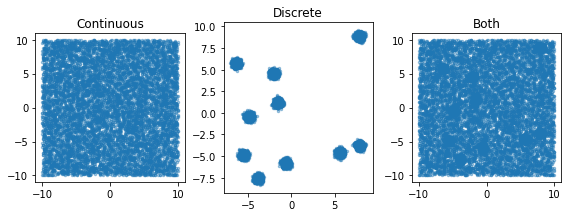

In [699]:
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(131)
ax1.scatter(X_cont[:, 0], X_cont[:, 1], s=6, alpha=0.4)
ax1.set_title('Continuous')
ax1.set_aspect('equal')
ax2 = fig.add_subplot(132)
ax2.scatter(X_disc[:, 0], X_disc[:, 1], s=6, alpha=0.4)
ax2.set_title('Discrete')
ax2.set_aspect('equal')
ax3 = fig.add_subplot(133)
ax3.scatter(X_both[:, 0], X_both[:, 1], s=6, alpha=0.4)
ax3.set_title('Both')
ax3.set_aspect('equal')
plt.tight_layout()
plt.show()

In [700]:
from sklearn.mixture import GaussianMixture

def gmm_est(X, Kmax=12):
    gmms = []
    losses = []    
    for k in range(1, Kmax + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            reg_covar=1e-6,
            n_init=5
        )
        gmm.fit(X)
        loss = gmm.score(X)
        
        gmms.append(gmm)
        losses.append(loss)
    return gmms, losses

In [701]:
Kmax = 12
ks = range(1, Kmax + 1)

start = time.time()
gmms_cont, loss_cont = gmm_est(X_cont, Kmax)
gmms_disc, loss_disc = gmm_est(X_disc, Kmax)
gmms_both, loss_both = gmm_est(X_both, Kmax)

print('K_max={}'.format(Kmax))
print('Time elapsed: {:.2f} s'.format(time.time() - start))
print('Num points cont: {}'.format(X_cont.size))
print('Num points disc: {}'.format(X_disc.size))
print('Num points both: {}'.format(X_both.size))

K_max=12
Time elapsed: 82.61 s
Num points cont: 20000
Num points disc: 40000
Num points both: 60000


In [702]:
area = (xmax - xmin) * (ymax - ymin)
loss_uniform = -np.log(area)
print('Log likelihood uniform: {}'.format(loss_uniform))

Log likelihood uniform: -5.991464547107982


In [703]:
score_cont = loss_cont - loss_uniform
score_disc = loss_disc - loss_uniform
score_both = loss_both - loss_uniform

print('Score continuous: {}'.format(score_cont))
print('Score discrete: {}'.format(score_disc))
print('Score both: {}'.format(score_both))

Score continuous: [-0.35140349 -0.27713449 -0.2249436  -0.19936225 -0.18118109 -0.14494665
 -0.12721621 -0.13793063 -0.13488809 -0.10226504 -0.09608    -0.08524917]
Score discrete: [-0.16157127  0.4391842   1.31731106  1.54121568  2.21089173  2.77888901
  3.11954347  3.39073791  3.65461949  3.8551605   3.8549731   3.85484737]
Score both: [-0.23233394  0.00222285  0.41877496  0.44572125  0.64007797  0.91217926
  0.97384167  1.43683807  1.597974    1.75761112  1.77054647  1.90048877]


In [704]:
K_best_cont = ks[np.argmax(score_cont)]
K_best_disc = ks[np.argmax(score_disc)]
K_best_both = ks[np.argmax(score_both)]
gmm_best_cont = gmms_cont[np.argmax(score_cont)]
gmm_best_disc = gmms_disc[np.argmax(score_disc)]
gmm_best_both = gmms_both[np.argmax(score_both)]

In [705]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def draw_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )
    ax.add_patch(ellipse)

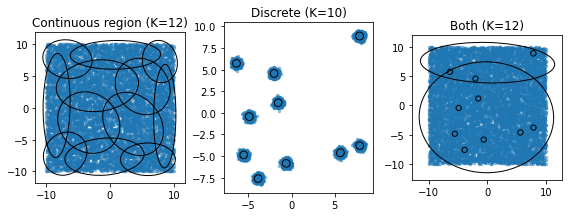

In [706]:
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(131)
ax1.scatter(X_cont[:, 0], X_cont[:, 1], s=6, alpha=0.4)
for mean, cov in zip(gmm_best_cont.means_, gmm_best_cont.covariances_):
    draw_ellipse(mean, cov, ax1)
ax1.set_title("Continuous region (K={})".format(K_best_cont))
ax1.set_aspect('equal')
ax2 = fig.add_subplot(132)
ax2.scatter(X_disc[:, 0], X_disc[:, 1], s=6, alpha=0.4)
for mean, cov in zip(gmm_best_disc.means_, gmm_best_disc.covariances_):
    draw_ellipse(mean, cov, ax2)
ax2.set_title("Discrete (K={})".format(K_best_disc))
ax2.set_aspect('equal')
ax3 = fig.add_subplot(133)
ax3.scatter(X_both[:, 0], X_both[:, 1], s=6, alpha=0.4)
for mean, cov in zip(gmm_best_both.means_, gmm_best_both.covariances_):
    draw_ellipse(mean, cov, ax3)
ax3.set_title("Both (K={})".format(K_best_both))
ax3.set_aspect('equal')
plt.tight_layout()
plt.show()

This method might work. If k=1 and k=2 (and k=3?) score is negative (I determined this empirically), then it means that the "uniform distribution" is favored. If k=1 is positive, then the discrete "gaussian mixed" case is favored. Then select the k value that is minimized. The current method seems sensitive to noise though or non-gaussian shape (such as a dense square cloud section), so this algorithm would need to be improved to isolate those cases or only be restricted to a diagnostic tool case (masking or flagging). 

I still think HDBSCAN might be best for identifying clusters individually but the modified Gaussian mixed model might be best as a masking tool. 

In [472]:
from sklearn.mixture import GaussianMixture

def bic_curve(X, Kmax=12):
    bics = []
    gmms = []
    for k in range(1, Kmax + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            reg_covar=1e-6,
            n_init=5
        )
        gmm.fit(X)
        bics.append(gmm.bic(X))
        gmms.append(gmm)
    return gmms, bics

In [473]:
Kmax = 2

start = time.time()
gmms_cont, bics_cont = bic_curve(X_cont, Kmax)
gmms_disc, bics_disc = bic_curve(X_disc, Kmax)
gmms_both, bics_both = bic_curve(X_both, Kmax)

print('K_max={}'.format(Kmax))
print('Time elapsed: {:.2f} s'.format(time.time() - start))
print('Num points: {}'.format(X_both.size))

K_max=2
Time elapsed: 0.14 s
Num points: 2030


C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Grant\anaconda3\envs\arsenl-conda\lib\site-packages\sklearn\cluster\_kmea

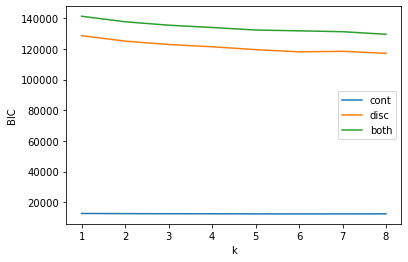

In [326]:
ks = range(1, Kmax + 1)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(ks, bics_cont, label='cont')
ax.plot(ks, bics_disc, label='disc')
ax.plot(ks, bics_both, label='both')
ax.set_ylabel('BIC')
ax.set_xlabel('k')
plt.legend()
plt.show()

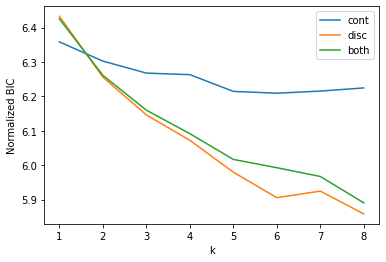

In [327]:
bics_cont_norm = np.array(bics_cont) / X_cont.size
bics_disc_norm = np.array(bics_disc) / X_disc.size
bics_both_norm = np.array(bics_both) / X_both.size

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(ks, bics_cont_norm, label='cont')
ax.plot(ks, bics_disc_norm, label='disc')
ax.plot(ks, bics_both_norm, label='both')
ax.set_ylabel('Normalized BIC')
ax.set_xlabel('k')
plt.legend()
plt.show()

In [328]:
K_best_cont = ks[np.argmin(bics_cont)]
K_best_disc = ks[np.argmin(bics_disc)]
K_best_both = ks[np.argmin(bics_both)]
gmm_best_cont = gmms_cont[np.argmin(bics_cont)]
gmm_best_disc = gmms_disc[np.argmin(bics_disc)]
gmm_best_both = gmms_both[np.argmin(bics_both)]

In [329]:
def covariance_scales(X, K):
    gmm = GaussianMixture(
        n_components=K,
        covariance_type='full',
        reg_covar=1e-6,
        n_init=5
    )
    gmm.fit(X)
    return [np.trace(cov) for cov in gmm.covariances_]

In [330]:
cov_cont = covariance_scales(X_cont, K=K_best_cont)
cov_disc = covariance_scales(X_disc, K=K_best_disc)
cov_both = covariance_scales(X_both, K=K_best_both)

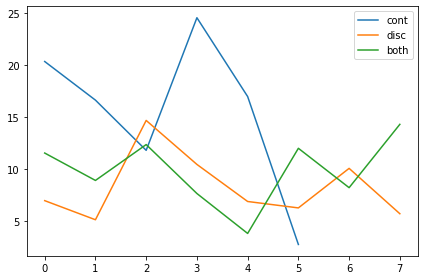

In [331]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(cov_cont, label='cont')
ax.plot(cov_disc, label='disc')
ax.plot(cov_both, label='both')
plt.legend()
plt.tight_layout()
plt.show()

In [332]:
complexity_cont = bics_cont[0] - min(bics_cont)
complexity_disc = bics_disc[0] - min(bics_disc)
complexity_both = bics_both[0] - min(bics_both)

print('Continuous complexity: {}'.format(complexity_cont))
print('Discrete complexity: {}'.format(complexity_disc))
print('Both complexity: {}'.format(complexity_both))

Continuous complexity: 298.31374257382777
Discrete complexity: 11498.775058269646
Both complexity: 11766.991288144753


In [333]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def draw_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )
    ax.add_patch(ellipse)

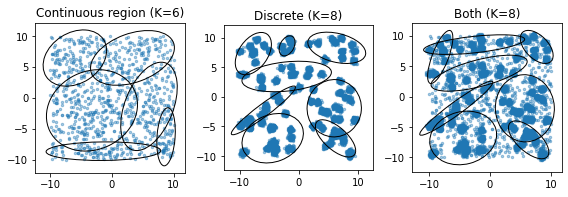

In [334]:
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(131)
ax1.scatter(X_cont[:, 0], X_cont[:, 1], s=6, alpha=0.4)
for mean, cov in zip(gmm_best_cont.means_, gmm_best_cont.covariances_):
    draw_ellipse(mean, cov, ax1)
ax1.set_title("Continuous region (K={})".format(K_best_cont))
ax1.set_aspect('equal')
ax2 = fig.add_subplot(132)
ax2.scatter(X_disc[:, 0], X_disc[:, 1], s=6, alpha=0.4)
for mean, cov in zip(gmm_best_disc.means_, gmm_best_disc.covariances_):
    draw_ellipse(mean, cov, ax2)
ax2.set_title("Discrete (K={})".format(K_best_disc))
ax2.set_aspect('equal')
ax3 = fig.add_subplot(133)
ax3.scatter(X_both[:, 0], X_both[:, 1], s=6, alpha=0.4)
for mean, cov in zip(gmm_best_both.means_, gmm_best_both.covariances_):
    draw_ellipse(mean, cov, ax3)
ax3.set_title("Both (K={})".format(K_best_both))
ax3.set_aspect('equal')
plt.tight_layout()
plt.show()